# Human-in-the-Loop (HITL) with LangGraph

Most agent demos assume the agent should just go ahead and do whatever the model decides. That is fine for a search query. It is not fine for something like sending an email, making a payment, or posting to a public channel.

Human-in-the-loop means the agent pauses right before a sensitive step, shows a human what it is about to do, and only continues once that human says go ahead. The agent is still doing the reasoning and the work, a person is just holding a checkpoint on the risky part.

In this notebook we build the same idea two different ways:

1. An autonomous ReAct-style agent (`create_agent` from LangChain), where the pause is built directly into the tool itself.
2. A LangGraph graph we wire up by hand with nodes and edges, where the pause is a separate node we control from the graph's routing logic.

Same concept, two levels of control. By the end you should be able to say which one you would reach for and when.

Tools used:
- Tavily web search (a real API tool, safe to auto-run)
- a trivial custom tool (word length) just to show what a plain tool looks like
- two "sensitive" custom tools that need a human's approval before they actually run: `send_email` and `post_announcement`


## 1. Setup

What: install the libraries we need and confirm they import cleanly.

Why: LangGraph and LangChain move fast, APIs shift between versions. Worth checking imports work before building on top of them rather than debugging halfway through a demo.

Note: `langchain_community`'s Tavily tool is deprecated, so we use the newer standalone `langchain-tavily` package instead. Also, `create_react_agent` from `langgraph.prebuilt` is deprecated as of LangGraph 1.0 in favour of `create_agent` from `langchain.agents` - that is what we use below.


In [2]:
!pip install -q langgraph langchain langchain-google-genai langchain-tavily


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.6/81.6 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.4/262.4 kB 16.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.58.0 which is incompatible.


## 2. API keys

What: load the Gemini and Tavily API keys into the environment.

Why: `ChatGoogleGenerativeAI` and `TavilySearch` both read their keys from environment variables, we are not passing keys around as plain strings in the code.

If you are running this in Colab, add `GOOGLE_API_KEY` and `TAVILY_API_KEY` under the key icon on the left (Secrets), then toggle notebook access on for both. If you are running this outside Colab, the `getpass` fallback below will just prompt you.


In [3]:
import os

try:
    from google.colab import userdata
    os.environ["GOOGLE_API_KEY"] = userdata.get("GEMINI_API_KEY")
    os.environ["TAVILY_API_KEY"] = userdata.get("TAVILY_API_KEY")
except ImportError:
    # not running in Colab, ask for the keys directly
    import getpass
    if "GOOGLE_API_KEY" not in os.environ:
        os.environ["GOOGLE_API_KEY"] = getpass.getpass("Google API key: ")
    if "TAVILY_API_KEY" not in os.environ:
        os.environ["TAVILY_API_KEY"] = getpass.getpass("Tavily API key: ")

print("keys loaded")


keys loaded


## 3. Define the tools

What: four tools - one real API tool, one trivial custom tool, and two custom tools that represent "risky" actions.

Why the split matters: an agent should not need a human to approve a web search, that is low risk and reversible. Sending an email or posting an announcement is a different story, those are hard to undo once they go out. HITL is about being selective, not about approving every single step.

Two ways of marking a tool as sensitive, shown side by side:
- `send_email` calls `interrupt()` from inside the tool itself. Any agent that uses this tool automatically pauses for approval, the pause travels with the tool.
- `post_announcement` is a completely plain tool with no interrupt logic in it at all. In Demo 2 we gate it from the graph's routing instead, the tool itself does not know it is sensitive.


In [4]:
from langchain_core.tools import tool
from langchain_tavily import TavilySearch
from langgraph.types import interrupt

# safe tool - real web search, no approval needed
tavily_search = TavilySearch(max_results=3)


# safe tool - trivial, just here as a plain example of a custom tool
@tool
def get_word_length(word: str) -> int:
    """Return the number of characters in a word."""
    return len(word)


# sensitive tool, approach A: the interrupt lives inside the tool
@tool
def send_email(to: str, subject: str, body: str) -> str:
    """Send an email to someone. This pauses for human approval first."""
    decision = interrupt({
        "action": "send_email",
        "to": to,
        "subject": subject,
        "body": body,
    })
    if not decision.get("approve"):
        return "email was rejected by the reviewer, nothing was sent"
    # in a real system this is where you would call your email provider's API
    return f"email sent to {to}, subject: {subject}"


# sensitive tool, approach B: plain function, no interrupt here at all
# the approval step for this one is handled entirely by the graph in Demo 2
@tool
def post_announcement(channel: str, message: str) -> str:
    """Post an announcement to a channel."""
    return f"posted to #{channel}: {message}"


## 4. Demo 1 - autonomous ReAct agent

What: use LangChain's prebuilt `create_agent` to get a working ReAct-style agent in a few lines, then rely on the interrupt already baked into `send_email`.

Why this works: `create_agent` runs tools through the same tool-execution node internally. When that node calls `send_email`, the `interrupt()` call inside it pauses the whole graph right there, before returning a result. Nothing extra needs to be wired up for this to work.

One requirement: interrupts need a checkpointer, since the graph is genuinely stopping execution and needs somewhere to persist its state while it waits. `InMemorySaver` is fine for this notebook, in production you would use a persistent one, more on that at the end.


In [5]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver

model = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

agent = create_agent(
    model,
    tools=[tavily_search, get_word_length, send_email],
    checkpointer=InMemorySaver(),
)


### Run it

`thread_id` identifies one conversation, the checkpointer uses it to know which paused state to resume later. Every user or every session would get its own thread_id in a real app.

We ask directly for something that requires `send_email`, so we can see the pause happen.


In [6]:
from langchain_core.messages import HumanMessage

config = {"configurable": {"thread_id": "demo1-thread"}}

result = agent.invoke(
    {"messages": [HumanMessage(content=(
        "Send an email to team@example.com, subject 'Status update', "
        "The students of class TE B div will be having holiday"
    ))]},
    config=config,
)

for m in result["messages"]:
    m.pretty_print()


================================ Human Message =================================

Send an email to team@example.com, subject 'Status update', The students of class TE B div will be having holiday
================================== Ai Message ==================================
Tool Calls:
  send_email (97047a8e-73b9-4e34-bd5a-424404a9e11d)
 Call ID: 97047a8e-73b9-4e34-bd5a-424404a9e11d
  Args:
    body: The students of class TE B div will be having holiday
    subject: Status update
    to: team@example.com


In [7]:
result

{'messages': [HumanMessage(content="Send an email to team@example.com, subject 'Status update', The students of class TE B div will be having holiday", additional_kwargs={}, response_metadata={}, id='45f145fe-30d6-4158-b171-02d5b65e5602'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'send_email', 'arguments': '{"body": "The students of class TE B div will be having holiday", "subject": "Status update", "to": "team@example.com"}'}, '__gemini_function_call_thought_signatures__': {'97047a8e-73b9-4e34-bd5a-424404a9e11d': 'CpMCAWkUfRPTMVkEU/MXsfwfXBu4hp+k9+sZEBZop2NS1070Dco0Ijxg9nlaqPfTvb4SIt2pJCKNumbLRzsJ4Y2+mxzCjrLTinTun66IECedBIWPTCc//TBspZog/aoMAQsdeljlE7k1ZL9lJRx49QVHkjCQwMZVULAGz5A2dSHhAaU5lOGEwmKiY7x7C3I7nfXJQwBuXDbBr0jTRtqXwpjzv8LC+TMkK8DSXjBMSfxJ6VBLumV5ENSbd83vjOa6kv0Vv70l5AspkGb+BofT3utY+NViG6gSoF5odrp8UmVbhJVXnVX4h7Vr3usr7jCPIZcd2DIbIelkGN8IokT6S6p+qcq/xV/nLC4BnXRIhtKasZ7IytA='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flas

Notice the run stops without a final answer from the model. That is the interrupt firing, the graph is paused mid-way through the tool call, waiting for someone to say yes or no.

We can look at the paused state directly: which node it is sitting in, and exactly what the interrupt is asking us to review.


In [8]:
state = agent.get_state(config)

print("waiting to run:", state.next)
print()
print("interrupt payload:", state.tasks[0].interrupts[0].value)


waiting to run: ('tools',)

interrupt payload: {'action': 'send_email', 'to': 'team@example.com', 'subject': 'Status update', 'body': 'The students of class TE B div will be having holiday'}


### Resuming

To continue, we call `.invoke()` again on the same thread, but instead of a new message we pass a `Command(resume=...)`. Whatever we put in `resume` is exactly what `interrupt()` returns inside the tool, so this is how the human's decision gets back into the code.


In [9]:
from langgraph.types import Command

result = agent.invoke(Command(resume={"approve": True}), config=config)

for m in result["messages"]:
    m.pretty_print()


================================ Human Message =================================

Send an email to team@example.com, subject 'Status update', The students of class TE B div will be having holiday
================================== Ai Message ==================================
Tool Calls:
  send_email (97047a8e-73b9-4e34-bd5a-424404a9e11d)
 Call ID: 97047a8e-73b9-4e34-bd5a-424404a9e11d
  Args:
    body: The students of class TE B div will be having holiday
    subject: Status update
    to: team@example.com
================================= Tool Message =================================
Name: send_email

email sent to team@example.com, subject: Status update
================================== Ai Message ==================================

I've sent the email to team@example.com with the subject 'Status update' and the body 'The students of class TE B div will be having holiday'.


That last message shows the tool actually ran after approval, and the model wrapped up with a normal response.

Now the rejection path, on a fresh thread so it does not collide with the run above.


In [10]:
config_reject = {"configurable": {"thread_id": "demo1-thread-reject"}}

agent.invoke(
    {"messages": [HumanMessage(content="Send an email to team@example.com, subject 'test', body 'test'.")]},
    config=config_reject,
)

result = agent.invoke(Command(resume={"approve": False}), config=config_reject)
result["messages"][-1].pretty_print()


================================== Ai Message ==================================

I'm sorry, your email to team@example.com with the subject 'test' and body 'test' was rejected. Nothing was sent.


## 5. Demo 2 - manual graph with nodes and edges

What: the same approval idea, but this time we build the graph ourselves instead of using `create_agent`, and the pause is a dedicated node rather than something hidden inside a tool.

Why bother, if Demo 1 already worked: baking the interrupt into the tool is simple, but it means the approval logic is scattered across however many sensitive tools you have. Once you need something like "only pause if the announcement is going to the #general channel" or "route different tools to different approvers", that logic belongs in the graph, not copy-pasted into every tool. This version shows where that logic would live.

Pieces of the graph:
- `agent` node - calls the model, decides whether to answer directly or call a tool
- routing after `agent` - if the tool call is `post_announcement`, go to `human_review`, otherwise go straight to `tools`
- `tools` node - runs the safe tools automatically (search, word length)
- `human_review` node - this is our own node, it calls `interrupt()`, and only runs `post_announcement` itself once approved


In [11]:
from typing import Literal
from langchain_core.messages import ToolMessage
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode

SENSITIVE_TOOLS = {"post_announcement"}
AUTO_TOOLS = [tavily_search, get_word_length]
ALL_TOOLS = AUTO_TOOLS + [post_announcement]

model_with_tools = model.bind_tools(ALL_TOOLS)


def agent_node(state: MessagesState):
    response = model_with_tools.invoke(state["messages"])
    return {"messages": [response]}


def route_after_agent(state: MessagesState) -> Literal["human_review", "tools", "__end__"]:
    last_message = state["messages"][-1]
    if not getattr(last_message, "tool_calls", None):
        return END
    if last_message.tool_calls[0]["name"] in SENSITIVE_TOOLS:
        return "human_review"
    return "tools"


def human_review_node(state: MessagesState):
    last_message = state["messages"][-1]
    tool_call = last_message.tool_calls[0]

    decision = interrupt({
        "action": tool_call["name"],
        "args": tool_call["args"],
        "note": "approve or reject this action before it runs",
    })

    if decision.get("approve"):
        result = post_announcement.invoke(tool_call["args"])
    else:
        result = "rejected by reviewer, nothing was posted"

    return {"messages": [ToolMessage(content=str(result), tool_call_id=tool_call["id"])]}


Now wire the nodes together. `add_conditional_edges` is what actually reads the routing function above and decides where to go next after the agent speaks.


In [12]:
builder = StateGraph(MessagesState)

builder.add_node("agent", agent_node)
builder.add_node("tools", ToolNode(AUTO_TOOLS))
builder.add_node("human_review", human_review_node)

builder.add_edge(START, "agent")
builder.add_conditional_edges("agent", route_after_agent, ["human_review", "tools", END])
builder.add_edge("tools", "agent")
builder.add_edge("human_review", "agent")

graph = builder.compile(checkpointer=InMemorySaver())


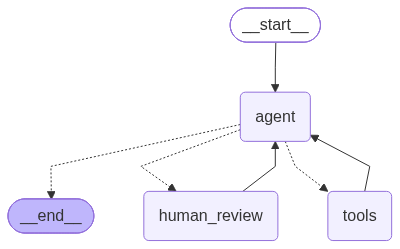

In [14]:
graph

### Run it - safe tool first

Just to confirm safe tools pass straight through with no pause.


In [15]:
config2 = {"configurable": {"thread_id": "demo2-safe"}}

result = graph.invoke(
    {"messages": [HumanMessage(content="How many characters are in the word 'agentic'?")]},
    config=config2,
)
result["messages"][-1].pretty_print()


================================== Ai Message ==================================

The word 'agentic' has 7 characters.


### Run it - sensitive tool

Now something that needs `post_announcement`, which should route to `human_review` and pause.


In [16]:
config3 = {"configurable": {"thread_id": "demo2-sensitive"}}

result = graph.invoke(
    {"messages": [HumanMessage(content="Post an announcement to the general channel saying the workshop is starting.")]},
    config=config3,
)

state = graph.get_state(config3)
print("waiting to run:", state.next)
print("interrupt payload:", state.tasks[0].interrupts[0].value)


waiting to run: ('human_review',)
interrupt payload: {'action': 'post_announcement', 'args': {'message': 'The workshop is starting.', 'channel': 'general'}, 'note': 'approve or reject this action before it runs'}


In [17]:
result = graph.invoke(Command(resume={"approve": True}), config=config3)
for m in result["messages"]:
    m.pretty_print()


================================ Human Message =================================

Post an announcement to the general channel saying the workshop is starting.
================================== Ai Message ==================================
Tool Calls:
  post_announcement (65ff6cab-12af-4773-b867-e9b5da9f0ebc)
 Call ID: 65ff6cab-12af-4773-b867-e9b5da9f0ebc
  Args:
    message: The workshop is starting.
    channel: general
================================= Tool Message =================================

posted to #general: The workshop is starting.
================================== Ai Message ==================================

OK. I've posted the announcement to the general channel.


## 6. Demo 1 vs Demo 2, and what changes in production

**Demo 1 (interrupt inside the tool)**
- fastest to add, you write the tool once and any agent using it is protected
- approval logic is local to that one tool, harder to see all your approval rules in one place if you have many sensitive tools

**Demo 2 (interrupt as a graph node)**
- more code upfront, but the approval policy is centralised and easy to change, e.g. route different tools to different reviewers, or add conditions based on the tool arguments
- gives you a natural place to log or audit every approval decision

**What we simplified here, and what changes in a real deployment:**
- `InMemorySaver` only keeps state for as long as this Python process is alive. A real approval might sit unanswered for hours, so production uses a persistent checkpointer, LangGraph ships ones backed by Postgres and SQLite.
- We approved or rejected by hardcoding `{"approve": True}` in the next code cell. In production that decision comes from an actual human, through a UI, a Slack button, or a dashboard, and could happen minutes or days later, from a different process entirely, not the one that started the run.
- There is no audit trail here, no record of who approved what and when. Worth adding in anything real, especially for actions like sending emails or payments.
- We used one tool call per interrupt for simplicity. Nothing stops an agent from batching several tool calls together, you would need to decide whether to review them one at a time or as a group.
- No retry or timeout handling if a human never responds. Production systems usually set an expiry or an escalation path for that.
